<a href="https://colab.research.google.com/github/vishwesh-V/virtue-of-complexity/blob/main/debate/Nagel/nagel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# =================================================================
# nagel.ipynb — Phase 3 critique (Nagel 2025)
# Claim: the "virtue" is volatility-timed momentum in disguise. In short
# windows the RFF timing forecast reduces to a recency-weighted, vol-scaled
# bet on recent returns. Counter-spec: build a plain vol-timed momentum
# strategy (NO predictors, NO RFF), aligned to the SAME bet horizon as KMZ,
# and measure how much of the KMZ Sharpe it mechanically explains.
# =================================================================
from google.colab import drive; drive.mount('/content/drive')
import pandas as pd, numpy as np, matplotlib.pyplot as plt

KMZ    = "/content/drive/MyDrive/Summer Research/kmz"
DEBATE = "/content/drive/MyDrive/Summer Research/debate"
MASTER_SEED = 42

# --- engine copied from kmz_pipeline.ipynb — keep in sync ---
def make_rff(G, n_pairs, gamma=2.0, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((G.shape[1], n_pairs))
    proj = gamma * (G @ W)
    return np.concatenate([np.sin(proj), np.cos(proj)], axis=1)

def ridge_forecast_dual(S_tr, R_tr, S_t, z):
    T = S_tr.shape[0]
    K = (S_tr @ S_tr.T) / T
    a = np.linalg.solve(K + z*np.eye(T), R_tr/T)
    return float(S_t @ (S_tr.T @ a))

def run_oos_nested(S_full, R, P, T, z):
    S_all = S_full[:, :P]; N = len(R); fc, sr = [], []
    for t in range(T, N):
        S_tr, R_tr = S_all[t-T:t], R[t-T:t]
        sd = S_tr.std(axis=0); sd[sd==0]=1.0
        f = ridge_forecast_dual(S_tr/sd, R_tr, S_all[t]/sd, z)
        fc.append(f); sr.append(f*R[t])
    return np.array(fc), np.array(sr)

def sharpe(x):
    return x.mean()/x.std()*np.sqrt(12)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
predictors = ["dp","dy","ep","de","svar","bm","ntis","tbl","lty","ltr",
              "tms","dfy","dfr","infl","mktret_lag"]
panel = pd.read_parquet(f"{KMZ}/predictors.parquet").sort_values("date").reset_index(drop=True)
panel["target"] = panel["excess_ret"].shift(-1)          # KMZ target: return_{t+1} on row t

def exp_std(s, mp=36):
    return s / s.expanding(min_periods=mp).std().shift(1)

std = panel.copy()
for c in predictors: std[c] = exp_std(panel[c])
std = std.dropna(subset=predictors+["target"]).reset_index(drop=True)

G = std[predictors].to_numpy()
R = std["target"].to_numpy()                 # aligned next-month excess return (KMZ target)
ret_series = std["excess_ret"].to_numpy()    # contemporaneous excess return (for momentum)
dates = std["date"].to_numpy()
print("data ready:", G.shape, R.shape)

data ready: (1152, 15) (1152,)


In [7]:
# =================================================================
# Vol-timed momentum benchmark — NO predictors, NO RFF.
# Position at t uses returns through t-1 (causal), applied to R[t]
# (the KMZ next-month target), so the bet horizon EXACTLY matches KMZ:
# both form the position from info through t-1 and earn the t->t+1 return.
# =================================================================
def vol_timed_momentum(ret_contemp, R_target, mom_window=12, vol_window=12):
    """
    ret_contemp : contemporaneous excess return (return realized during month t)
    R_target    : aligned next-month return (R[t] = return over t -> t+1), KMZ's target
    position at t = (trailing mean return) / (trailing vol), using data through t-1,
    earned return = position * R_target[t]  -> same horizon as the KMZ strategy.
    """
    N = len(R_target)
    start = max(mom_window, vol_window)
    strat = []
    for t in range(start, N):
        mom = ret_contemp[t-mom_window:t].mean()                 # info through t-1
        vol = np.sqrt((ret_contemp[t-vol_window:t]**2).mean())   # info through t-1
        pos = mom / (vol + 1e-8)
        strat.append(pos * R_target[t])                          # earn t->t+1 return
    return np.array(strat), start

mom_strat, mom_start = vol_timed_momentum(ret_series, R)
mom_sharpe = sharpe(mom_strat)
print(f"Vol-timed momentum Sharpe (aligned, no predictors/RFF): {mom_sharpe:.3f}")
print(f"months: {len(mom_strat)}  ({pd.Timestamp(dates[mom_start]).date()} onward)")

Vol-timed momentum Sharpe (aligned, no predictors/RFF): 0.283
months: 1140  (1930-12-01 onward)


In [8]:
# Compare like-for-like: momentum is a single deterministic run, so compare it to a
# SINGLE-draw KMZ run (not the 20-draw average), over the same annualization.
S_full = make_rff(G, n_pairs=6000, gamma=2.0, seed=MASTER_SEED*100000 + 0)
_, kmz_strat = run_oos_nested(S_full, R, P=12000, T=12, z=1e-3)   # highest complexity, 1 draw
kmz_sharpe_1draw = sharpe(kmz_strat)

# align to the same months (both should cover the overlapping period)
print(f"momentum Sharpe          : {mom_sharpe:.3f}  (n={len(mom_strat)})")
print(f"KMZ P=12000 single-draw  : {kmz_sharpe_1draw:.3f}  (n={len(kmz_strat)})")
print(f"KMZ P=12000 20-draw avg  : 0.161  (from Phase 2)")

momentum Sharpe          : 0.283  (n=1140)
KMZ P=12000 single-draw  : 0.146  (n=1140)
KMZ P=12000 20-draw avg  : 0.161  (from Phase 2)


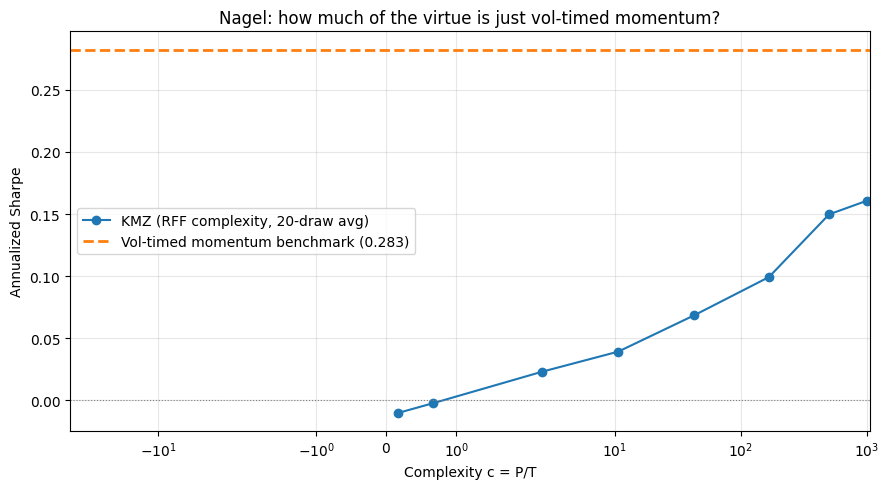

In [9]:
kmz = pd.read_parquet(f"{KMZ}/kmz_sweep_avg.parquet")

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(kmz["complexity"], kmz["sharpe"], "o-", label="KMZ (RFF complexity, 20-draw avg)")
ax.axhline(mom_sharpe, color="C1", ls="--", lw=2,
           label=f"Vol-timed momentum benchmark ({mom_sharpe:.3f})")
ax.set_xscale("symlog"); ax.axhline(0, color="grey", lw=.8, ls=":")
ax.set_xlabel("Complexity c = P/T"); ax.set_ylabel("Annualized Sharpe")
ax.set_title("Nagel: how much of the virtue is just vol-timed momentum?")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
fig.savefig(f"{DEBATE}/nagel_momentum.png", dpi=150, bbox_inches="tight")